# Przygotowanie

Przygotowanie Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko. {nr_albumu}_{imię}_{nazwisko}_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez platformę TEAMS.

# Drzewa decyzyjne

Podobnie jak w przypadku maszyny wektorów nosnych (SVC), drzewa decyzyjne sa wszechstronnym algorytmem uczenia maszynowego. Mogą słuzyc do rozwiazywania problemów zarówno klasyfikacji, jak i regresji. W przeciwieństwie do modelu SVC drzewa decyzyjne nie wymagają restrykcyjnego przygotowania danych (np. skalowania cech). Drzewa decyzyjne składaja sie z korzenia oraz gałezi prowadzacych do kolejnych wierzchołków. W wezłach - wierzchołkach z których wychodzi co najmniej jedna krawedź, sprawdzany jest pewien warunek. Na jego podstawie, wybierana jest gałaz prowadząca do kolejnego wierzchołka. Dana obserwacja zostaje zaklasyfikowana do konkretnej klasy po przejściu od korzenia do liscia i przypisaniu do tej obserwacji klasy, z danego liscia (nie wychodza z niego wezły potomne).

Za pomocą drzew decyzyjnych otrzymać możemy potężne modele zdolne do nauki złożonych zbiorów danych.

###  Las losowy

Klasyfikator lasu losowego jest klasyfikatorem zespołowym złozonym z drzew decyzyjnych. Klasyfikator ten wprowadza dodatkową losowość do wzrostu drzew. Nie wyszukuje on najlepszej cechy podczas podziału na wezły, ale szuka najlepszej cechy wsród losowego podziału cech. Powoduje to wieksze zróznicowanie powstałych w klasyfikatorze drzew. Losowe lasy są bardziej odporne na nadmierne dopasowanie się do zbioru treningowego, jakie spotykane jest podczas użycia drzew decyzyjnych.

In [1]:
import pandas as pd
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
#data = pd.read_csv()
#colA = data['colA'].values.T
X = iris.data[:, [2, 3]]
y = iris.target

print('Class labels:', np.unique(y))

Class labels: [0 1 2]


In [2]:
unique, counts = np.unique(y, return_counts=True)
dict(zip(unique, counts))

{0: 50, 1: 50, 2: 50}

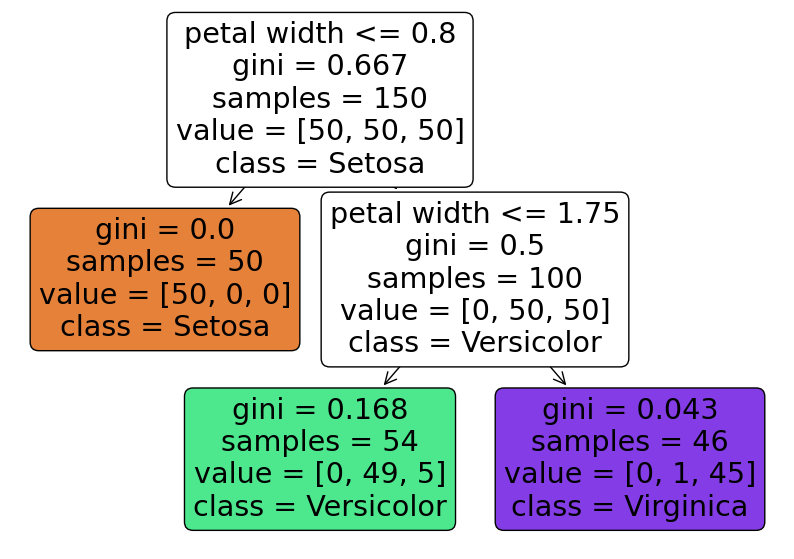

In [3]:
import matplotlib.pyplot as plt
from pydotplus import graph_from_dot_data
from sklearn.tree import DecisionTreeClassifier, export_graphviz

from sklearn.tree import plot_tree

tree = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=1)
tree.fit(X, y)

plt.figure(figsize=(10, 7))

plot_tree(tree, 
          filled=True, 
          rounded=True,
          class_names=['Setosa', 
                       'Versicolor',
                       'Virginica'],
          feature_names=['petal length', 
                         'petal width']) 

plt.show()

### Jak podejmowane są decyzje w drzewie?

Klasyfikacja próbki zaczyna się zawsze od korzenia (węzeł na samej górze grafu). W węźle zadawane jest pytanie (w przykładnie powyżej czy długość płatka jest mniejsza od 0.8). Jeśli prawda przechodzimy do węzła potomnego lewego, w przeciwnym razie do prawego. Przechodząc do węzła lewego dochodzimy do **liścia** (leaf node, nie posiada węzłów potomnych) - w taki wypadku żadne pytanie nie jest zadawane, przydzielana jest już tylko klasa do danej obserwacji. 

W przypadku, gdy skierujemy się ku węzłowi prawemu (nie jest już liściem) zadajemy kolejne pytanie, aż dojdziemy do liścia.

Znaczenie atrybutów:

- *samples* - oznacza ilość wyznaczonych próbek dla danego węzła (zgadza się to w przedstawionym przypadku z ilością próbek dla danych klas)
- *value* - określa ilość przykładów uczących z każdej klasy jakie przynależą do danego węzła.
- *gini* - miara zanieczyszczenia węzła (0 oznacza, że wszystkie próbki w węźle należą do jednej klasy - idealna klasyfikacja)

Wskaźnik Gingiego:
    \begin{equation*}
 G_{i} = 1 - \sum_{k=1}^{n} p_{i, k}^{2}
\end{equation*}
gdzie $p_{i,k}$ oznacza współczynie występowania klas k, wśród próbek uczących w węźle i.

Jako wskaźnik zanieczyszczenia (parametr *entropy*), użyta może zostać również miara entropii. Wynosi ona 0, w przypadku, gdy wszystkie informacje są takie same - wszystkie próbiki w węźle należą do jednej klasy.

Entropia:
    
\begin{equation*}
    H_{i} = - \sum_{k=1\\ p_{i,k} \neq 0}^{n} p_{i, k} log(p_{i,k})
\end{equation*}


Różnice pomędzy tymi dwoma miarami są zazwyczaj bardzo znikome i nie wypływają znacząco na skuteczność działania klasyfikatora. Dla zainteresowanych szczegółami zapraszam do lektury: https://sebastianraschka.com/faq/docs/decision-tree-binary.html, https://towardsdatascience.com/the-simple-math-behind-3-decision-tree-splitting-criterions-85d4de2a75fe

W jakim momencie przestać budować drzewo decyzyje?

Problemy rozważane w uczeniu maszynowym mają zazwyczaj sporą liczbę cech, która może powodować wysoko rosnące skomplikowanie drzewa (jego wielkość, sporą ilość węzłów oraz podziałów w węzłach). Tak utworzone drzewa mogą powodować nadmierne dopasowanie do danych treningowych.

Algorytm drzewa decyzyjnego posiada parametry, które ustalane są podczas uczenia. Jak wspomniano, może powodować to przetrenowanie klasyfikatora (nadmierne dopasowanie do danych uczących). Aby tego uniknąć, dobrym rozwiązaniem okazuje się ograniczenie swobody działania klasyfikatora. Podobnie jak w przypadku klasyfikatora SVC, również dla drzewa decyzyjnego zdefinowane zostały parametry regularyzacyjne:

- *max_depth* - maksymalna wysokość drzewa
- *min_samples_split* - minimalna liczba próbek, jakie będą w węźle (przed podziałem)
- *min_samples_leaf* - minimalna liczba próbek, jakie będą w liściu
- *max_leaf_nodes* - maksymalna ilość liści
- *max_features* - maksymalna liczba cech używana do dzielenia węzła.

Modyfikacja tych parametrów powoduje regularyzację drzewa i zmniejsza ryzyko przetrenowania.

## Zadania

### Zadanie 1

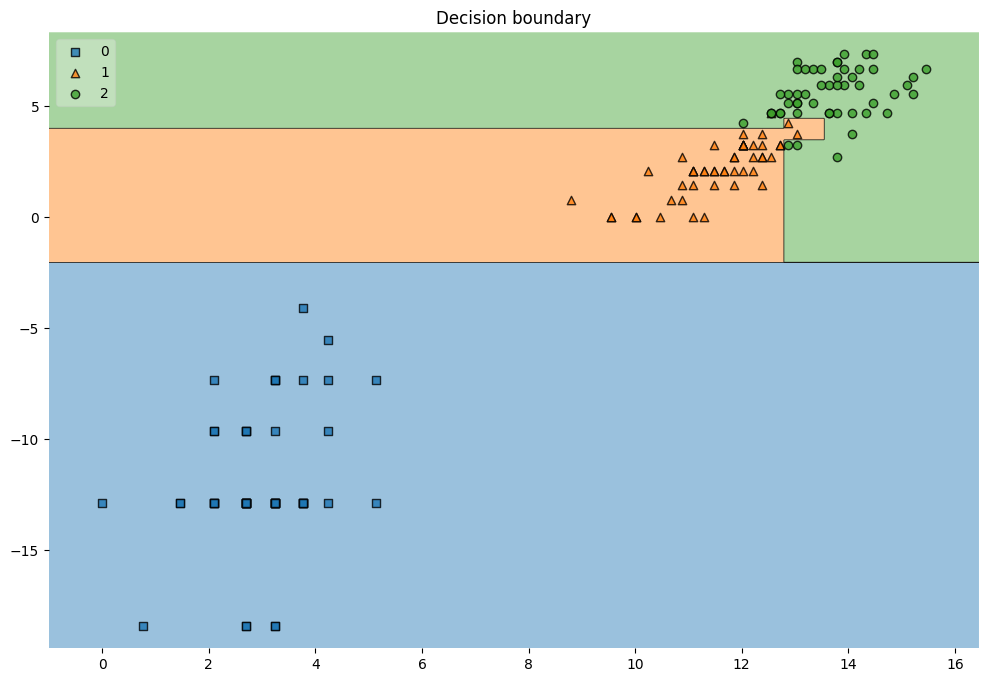

In [4]:
from mlxtend.plotting import plot_decision_regions

tree = DecisionTreeClassifier(max_depth=10, criterion="entropy", random_state=1)
tree.fit(np.log(X ** 8), y)
fig = plt.figure(figsize=(12,8))
labels = ['Decision Tree']
fig = plot_decision_regions(X=np.log(X ** 8), y=y, clf=tree, legend=2)
plt.title("Decision boundary")
plt.show()

##### Jakie wnioski możne sformuować na bazie granic decyzyjnych przedstawionych powyżej? W momencie pojawianie się dodatkowej próbki klasy *zielonej* (2), zostanie ona dobrze sklasyfikowana? Czy klasyfikator posiada dobre właściwości generalizujące?

Wyznaczone granice sa precyzyjne - zbyt precyzyjne. W przypakdu nowych dnayhc tak wyuczony klasyfikator może nie posiadac umięjemtności dobrego dopasowania, ponieważ nie posiada dobrych właściwości generalizujących. Klasy 1 i 2 są ułożone blisko siebie przez co tak głębokie drzewo (10 poziomów) próbuje je usilnie oddzielić, tracąc umiejętności generalizacji problemu.

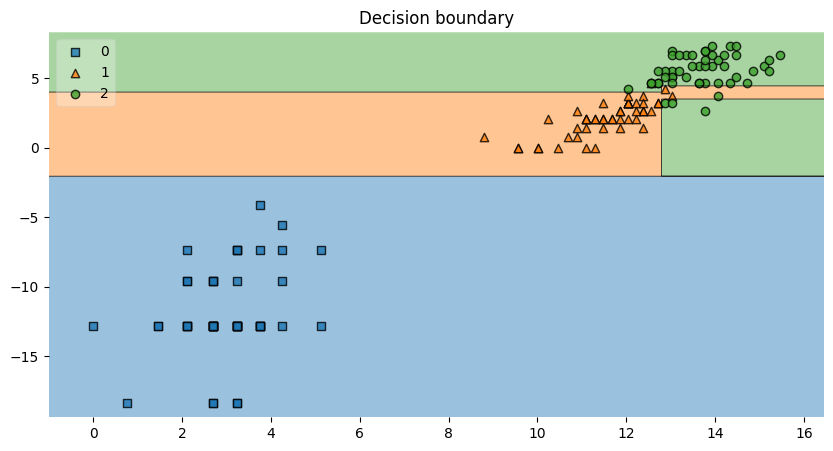

In [5]:
tree = DecisionTreeClassifier(max_depth=4, criterion="entropy", random_state=1)
tree.fit(np.log(X ** 8), y)
fig = plt.figure(figsize=(10,5))
labels = ['Decision Tree']
fig = plot_decision_regions(X=np.log(X ** 8), y=y, clf=tree, legend=2)
plt.title("Decision boundary")
plt.show()

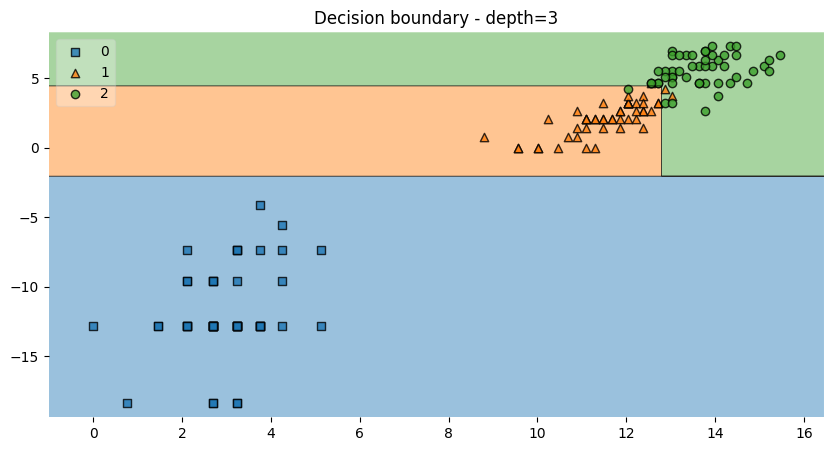

In [6]:
tree = DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=1)
tree.fit(np.log(X ** 8), y)
fig = plt.figure(figsize=(10,5))
labels = ['Decision Tree']
fig = plot_decision_regions(X=np.log(X ** 8), y=y, clf=tree, legend=2)
plt.title("Decision boundary - depth=3")
plt.show()

Powyższy wykres przedstawia lepszą granicę decyzyjną, taki klasyfikator będzie lepiej działał dla nowych punktów.

### Zadanie 2

Proszę o wczytanie, opisanie zbioru danych: https://www.kaggle.com/datasets/mathchi/diabetes-data-set. Proszę o usunięcie danych None. Zbiór danych powinien być użyty do dalszych oblicze

In [7]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
import numpy as np

df_test = pd.DataFrame({
    "A": [1, None, 3],
    "B": [None, None, 4],
    "C": ["x", None, "y"]
})

print(df_test.isna())
print(df_test.isnull())
# obie funkcje wyłapałyby wartości None

       A      B      C
0  False   True  False
1   True   True   True
2  False  False  False
       A      B      C
0  False   True  False
1   True   True   True
2  False  False  False


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Przejrzano zbiór danych, nie ma w nim danych brakujących.

### Zadanie 3

Proszę wytrenować zbiór z użyciem algorytmu drzewa decyzyjnego. Proszę pamiętać o odpowienim podziale na zbiór uczący i treningowy. Klasyfikator powinien być trenowany na zbiorze treningowym, a wynik jego skuteczności po trenowaniu obliczany w oparciu o zbiór testowy.

Proszę przygotować wyniki, trenując algorytm z użyciem różnych parametrów - należy przygotować wykresy (oś pionowa określa skuteczność, pozioma wartość parametru) pokazujące jak zmienia się skuteczność działania w zależności od zastosowanych wartości parametrów. Proszę o przygotowanie odpowiedniego porównania (tabela), co można zaobserwować?

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [14]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
# Pierwsza pojedyncza próba
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
acc = accuracy_score(y_test, y_pred) * 100

print(f"Skuteczność: {acc:.2f}%")

Skuteczność: 72.73%


In [16]:
def test_tree_param(
    X_train, X_test, y_train, y_test,
    param_name,
    param_values,
    fixed_params=None,
    random_state=42
):
    """
    Testuje wpływ jednego parametru drzewa decyzyjnego na skuteczność.

    param_name   – nazwa parametru (np. 'max_depth')
    param_values – lista wartości parametru
    fixed_params – słownik pozostałych parametrów (np. {'criterion': 'gini'})
    """

    if fixed_params is None:
        fixed_params = {}

    results = []

    for value in param_values:
        params = fixed_params.copy()
        params[param_name] = value

        tree = DecisionTreeClassifier(
            random_state=random_state,
            **params
        )

        tree.fit(X_train, y_train)
        y_pred = tree.predict(X_test)

        acc = accuracy_score(y_test, y_pred) * 100

        results.append({ param_name: value, "accuracy": acc})

    results_df = pd.DataFrame(results)
    plt.figure(figsize=(8,5))
    plt.plot(
        results_df[param_name],
        results_df["accuracy"],
        marker = 'o',
        color = '#b282ed'
    )
    plt.xlabel(param_name)
    plt.ylabel("Skuteczność % (zbiór testowy)")
    plt.title(f"Wpływ parametru {param_name} na skuteczność")
    plt.grid(True)
    plt.show()

    return results_df

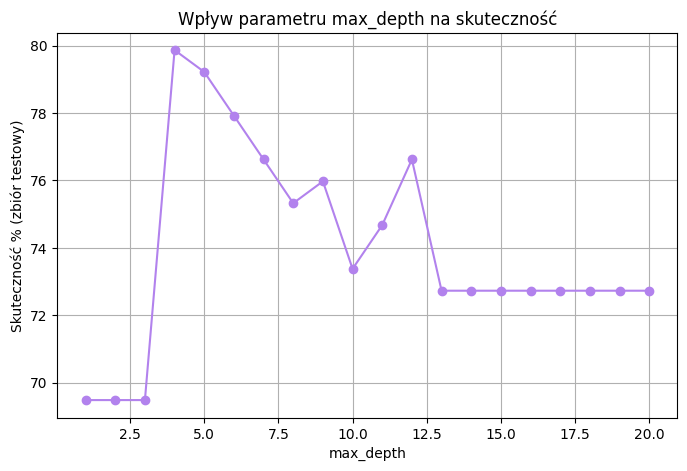

,max_depth,accuracy
3,4,79.870130
4,5,79.220779
5,6,77.922078
6,7,76.623377
11,12,76.623377


In [17]:
depths = range(1, 21)

results_depth = test_tree_param(
    X_train, X_test, y_train, y_test,
    param_name="max_depth",
    param_values=depths
)

results_depth.sort_values("accuracy", ascending=False).head()

#### Test zmiany kryterium dla dwóch najlepszych wartości max_depth

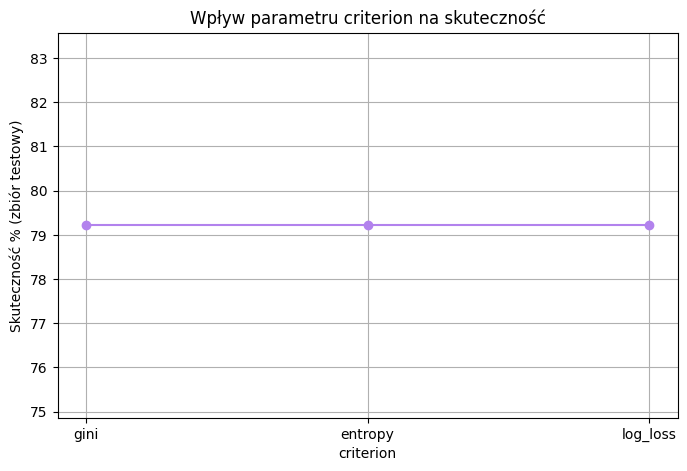

In [18]:
criteria = ["gini", "entropy", "log_loss"]

results_criterion = test_tree_param(
    X_train, X_test, y_train, y_test,
    param_name="criterion",
    param_values=criteria,
    fixed_params={"max_depth": 5}
)

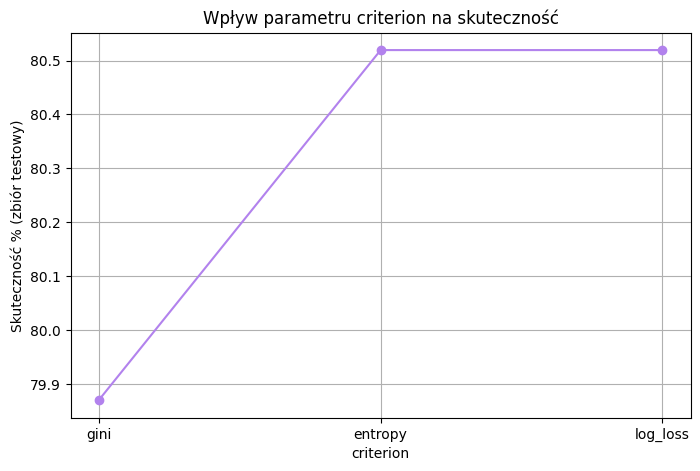

In [19]:
criteria = ["gini", "entropy", "log_loss"]

results_criterion = test_tree_param(
    X_train, X_test, y_train, y_test,
    param_name="criterion",
    param_values=criteria,
    fixed_params={"max_depth": 4}
)

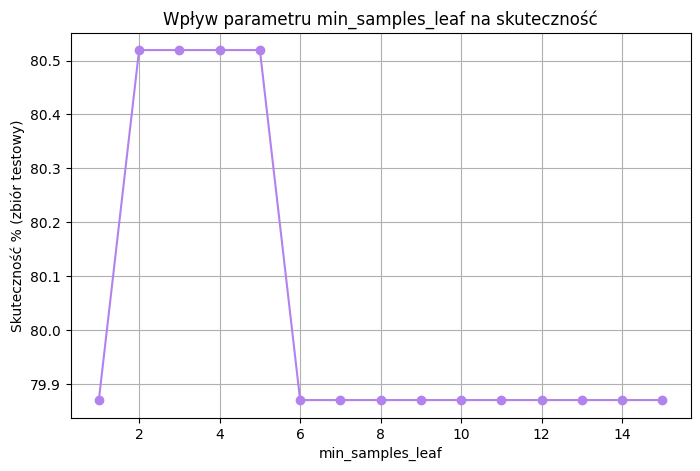

In [20]:
leaf_sizes = range(1, 16)

results_leaf = test_tree_param(
    X_train, X_test, y_train, y_test,
    param_name="min_samples_leaf",
    param_values=leaf_sizes,
    fixed_params={"max_depth": 4}
)

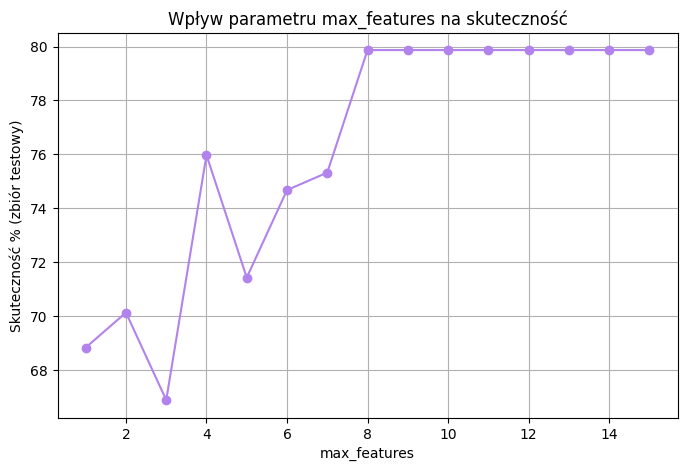

In [21]:
leaf_sizes = range(1, 16)

results_features = test_tree_param(
    X_train, X_test, y_train, y_test,
    param_name="max_features",
    param_values=leaf_sizes,
    fixed_params={"max_depth": 4}
)

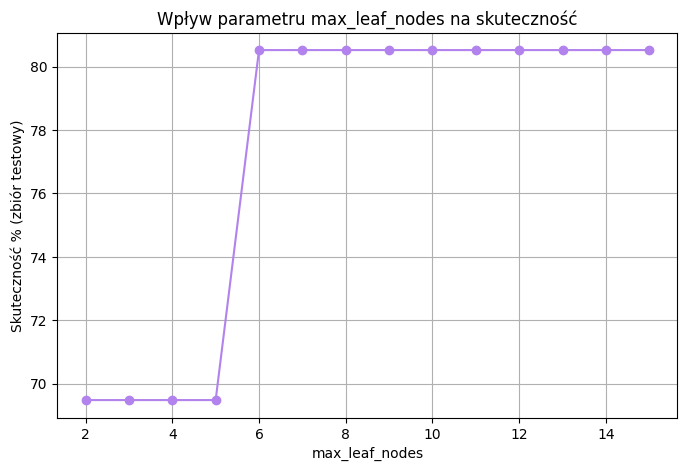

In [22]:
leaf_sizes = range(2, 16)

results_nodes = test_tree_param(
    X_train, X_test, y_train, y_test,
    param_name="max_leaf_nodes",
    param_values=leaf_sizes,
    fixed_params={"max_depth": 4, "criterion": "entropy"}
)

In [23]:
# Tabela podsumowująca
results_depth["parameter"] = "max_depth"
results_criterion["parameter"] = "criterion"
results_leaf["parameter"] = "min_samples_leaf"
results_features["parameter"] = "max_features"
results_nodes["parameter"] = "max_leaf_nodes"

results_depth = results_depth.rename(columns={"max_depth": "value"})
results_criterion = results_criterion.rename(columns={"criterion": "value"})
results_leaf = results_leaf.rename(columns={"min_samples_leaf": "value"})
results_features = results_features.rename(columns={"max_features": "value"})
results_nodes = results_nodes.rename(columns={"max_leaf_nodes": "value"})

summary = pd.concat([
    results_depth, 
    results_criterion, 
    results_leaf, 
    results_features, 
    results_nodes
], ignore_index=True)

summary.accuracy = summary.accuracy.round(4)

summary.sort_values("accuracy", ascending=False).head(5)

,value,accuracy,parameter
66,15,80.5195,max_leaf_nodes
59,8,80.5195,max_leaf_nodes
22,log_loss,80.5195,criterion
24,2,80.5195,min_samples_leaf
25,3,80.5195,min_samples_leaf


#### Najlepsze wartości dla poszczególnych parametrów

In [24]:
best_per_param = summary.groupby("parameter").apply(lambda df: df.nlargest(1, "accuracy")).reset_index(drop=True)

best_per_param

,value,accuracy,parameter
0,entropy,80.5195,criterion
1,4,79.8701,max_depth
2,8,79.8701,max_features
3,6,80.5195,max_leaf_nodes
4,2,80.5195,min_samples_leaf


In [25]:
best_tree = DecisionTreeClassifier(
    max_depth=4,
    max_features=8,
    max_leaf_nodes=6,
    min_samples_leaf=3,
    criterion="entropy",
    random_state=42
)

best_tree.fit(X_train, y_train)

y_pred = best_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy dla najlepszego zestawu parametrów: {accuracy:.2f}%")

Accuracy dla najlepszego zestawu parametrów: 80.52%


In [30]:
best_tree = DecisionTreeClassifier(
    max_depth=4,
    max_features=8,
    max_leaf_nodes=6,
    min_samples_leaf=3,
    criterion="gini",
    random_state=42
)

best_tree.fit(X_train, y_train)

y_pred = best_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy dla najlepszego zestawu parametrów: {accuracy:.2f}%")

Accuracy dla najlepszego zestawu parametrów: 79.87%


#### Testy kombinacji parametrów

In [31]:
from itertools import product

max_depth_values = [4, 5]
criterion_values = ["gini", "entropy"]
min_samples_leaf_values = [2, 3]
max_features_values = [8, 10]
max_leaf_nodes_values = [6, 8]

# Tworzymy wszystkie możliwe kombinacje
combinations = list(product(
    max_depth_values,
    criterion_values,
    min_samples_leaf_values,
    max_features_values,
    max_leaf_nodes_values
))

results = []

# Testujemy każdą kombinację
for max_depth, criterion, min_samples_leaf, max_features, max_leaf_nodes in combinations:
    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        criterion=criterion,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        max_leaf_nodes=max_leaf_nodes,
        random_state=42
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results.append({
        "max_depth": max_depth,
        "criterion": criterion,
        "min_samples_leaf": min_samples_leaf,
        "max_features": max_features,
        "max_leaf_nodes": max_leaf_nodes,
        "accuracy": round(acc * 100, 2)  # w %
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("accuracy", ascending=False).reset_index(drop=True)

results_df.head(10)

,max_depth,criterion,min_samples_leaf,max_features,max_leaf_nodes,accuracy
0,5,entropy,3,10,8,80.52
1,4,entropy,2,10,8,80.52
2,5,entropy,2,8,6,80.52
3,5,entropy,2,8,8,80.52
4,5,entropy,2,10,6,80.52
5,4,entropy,3,10,8,80.52
6,4,entropy,3,10,6,80.52
7,4,entropy,3,8,8,80.52
8,4,entropy,3,8,6,80.52
9,4,entropy,2,10,6,80.52


#### Wnioski
Przetestowane różne wartości poszczególnych parametrów prezentując wyniki na pojedynczych wykresach. Na przykładzie parametru **criterion** i liczenia skuteczności przy jego różnych wariantach można zaobserwować, że będzie ona zależała również od doboru pozostałych parametrów (różne wyniki dla max_depth=4 i 5). Oznaczałoby to, że zbiór najlepszych paramterów osobno nie musi gwarantować maksymalnej dokładności modelu. W celu jeszcze lepszego doboru parametrów należy testować różne kombinacje parametrów jednocześnie.

### Zadanie 4

Drzewa decyzyjne mogą również szacować przewdopodobieństwo przynależności danej próbki do określonej klasy. Proszę przeprowadzić odpowiednie trenowanie klasyfikatora i określić jak zmienia się prawdopodobieństwo przynależności różnych próbek. Wystarczy odnaleźć odpowienią właściwość klasyfikatora i pokazać jakie jest zwracane prawdopodobieństwo dla kilku przykładów.

In [41]:
clf = DecisionTreeClassifier(
    max_depth=4,
    criterion="entropy",
    min_samples_leaf=2,
    max_features=8,
    max_leaf_nodes=6,
    random_state=42
)

clf.fit(X_train, y_train)
samples = X_test[:5]

proba = clf.predict_proba(samples) * 100

# Wyświetlamy klasy
print(f"Klasy: {clf.classes_}")

for i, p in enumerate(proba):
    p_formatted = [f"{x:.2f}%" for x in p]
    true_class = y_test.iloc[i] if hasattr(y_test, "iloc") else y_test[i]
    print(f"Próbka {i}: prawdopodobieństwa przynależności do klas = {p_formatted}, prawdziwa klasa = {true_class}")

Klasy: [0 1]
Próbka 0: prawdopodobieństwa przynależności do klas = ['16.16%', '83.84%'], prawdziwa klasa = 0
Próbka 1: prawdopodobieństwa przynależności do klas = ['71.21%', '28.79%'], prawdziwa klasa = 0
Próbka 2: prawdopodobieństwa przynależności do klas = ['86.67%', '13.33%'], prawdziwa klasa = 0
Próbka 3: prawdopodobieństwa przynależności do klas = ['43.86%', '56.14%'], prawdziwa klasa = 1
Próbka 4: prawdopodobieństwa przynależności do klas = ['95.97%', '4.03%'], prawdziwa klasa = 0


Wartość prawdopodobieństwa przynależności zamiast jednoznaczej decyzji pozwala zobaczyć, z jaką pewnością model przypisuje próbki do klas. Na powyższym przykładzie widać również pomyłkę modelu, gdy największe prawdopodobieńśtwo przypadło na klasę inną niż prawdziwa.

### Zadanie 5

Proszę wyrysować granice decyzyjne dla klasyfikatora drzewa decyzyjnego utworzonego we wcześniejszym zadaniu. Jakie można sformuować wnioski?

In [42]:
print(X_train.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')


C:\Users\Iza\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


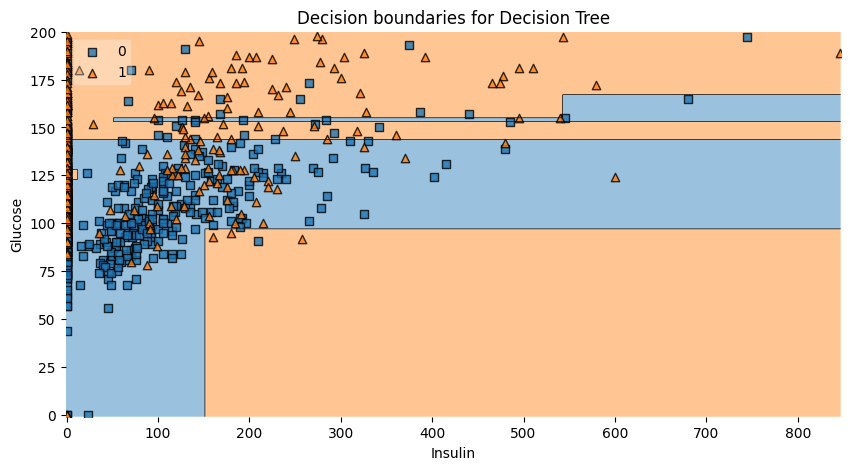

In [48]:
from matplotlib.colors import ListedColormap

X_2d = X[['Insulin', 'Glucose']]

tree = DecisionTreeClassifier(max_depth=4, criterion="entropy", random_state=1)
tree.fit(X_2d, y)

plt.figure(figsize=(10,5))
plot_decision_regions(X=X_2d.values, y=y.values, clf=tree, legend=2)
plt.xlabel(X_2d.columns[0])
plt.ylabel(X_2d.columns[1])
plt.title("Decision boundaries for Decision Tree")
plt.show()

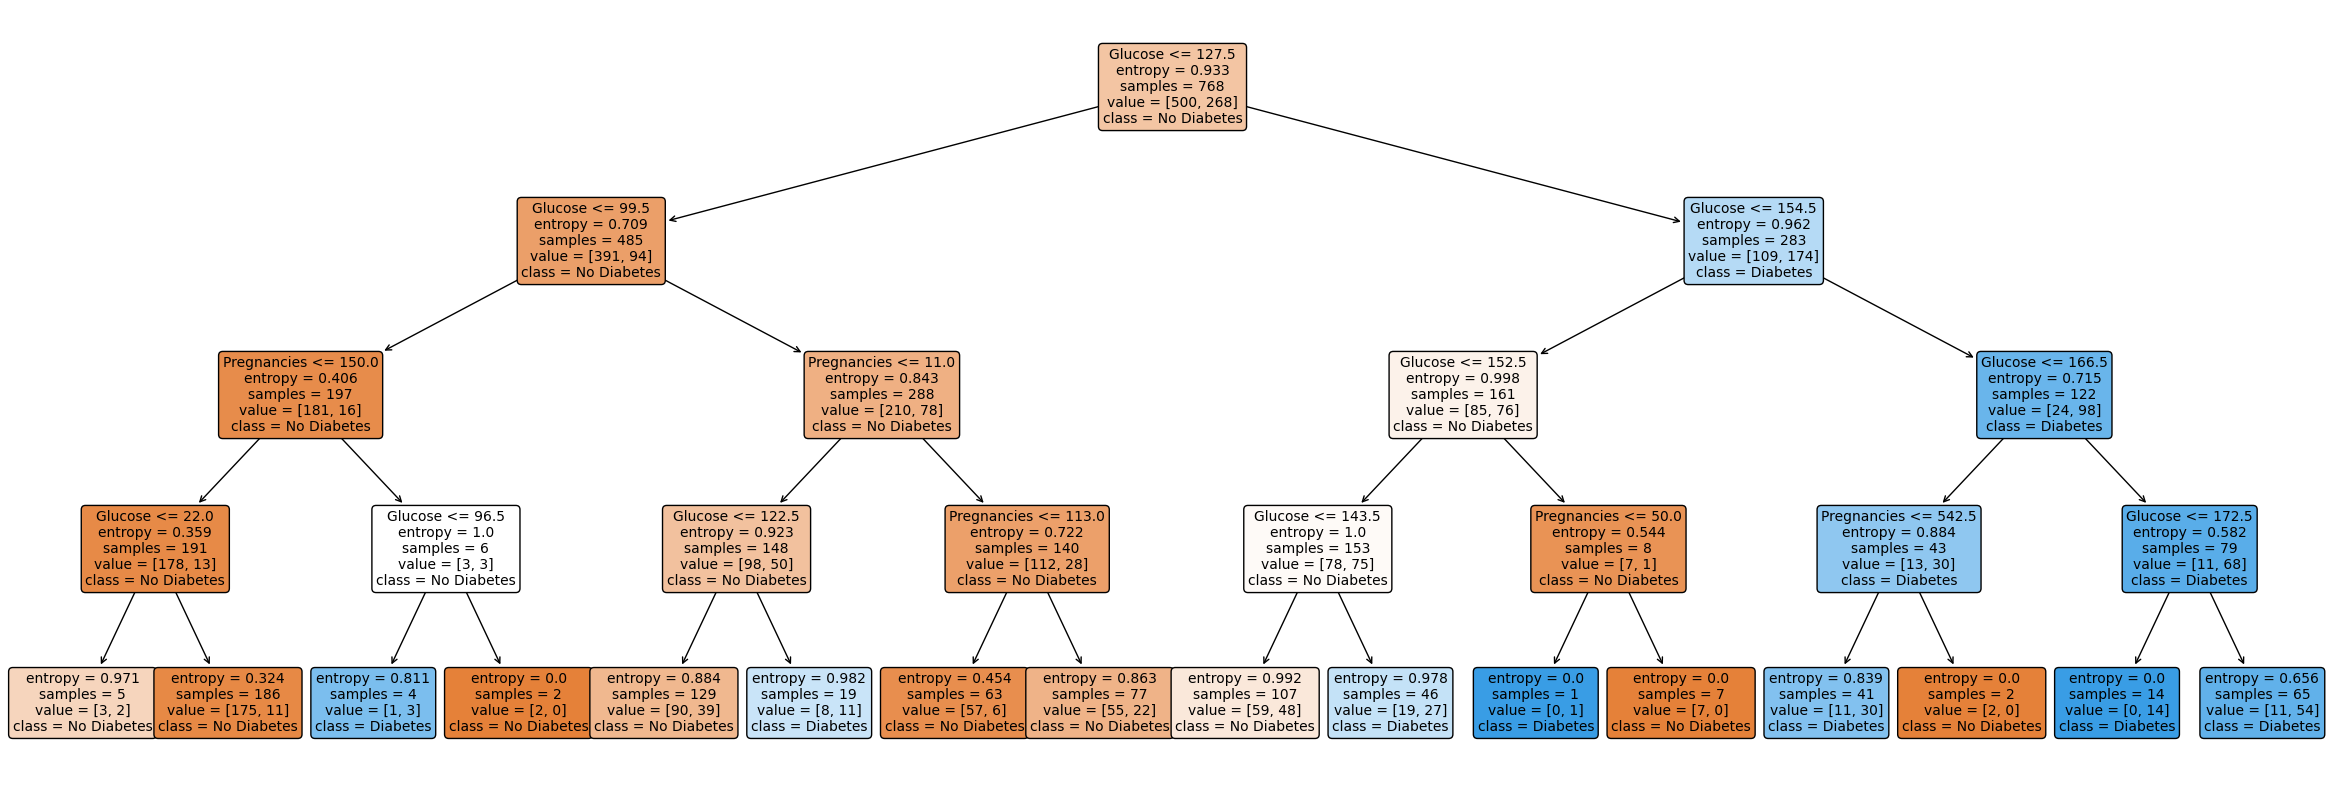

In [50]:
plt.figure(figsize=(30, 10))

plot_tree(tree, 
          filled=True, 
          rounded=True,
          class_names=['No Diabetes', 'Diabetes'],
          feature_names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                         'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
          fontsize=10) 

plt.show()

Wyznaczone granice decyzyjne można było pokazać jedynie przy pomocy różnych kombinacji 2 parametrów. Wybrano Insulinę i Glukozę - sprawdzono granicę dla innych kombinacji. Dokładność modelu nie będzie więc zbyt dobrze przedstawiona i nie należy wyciągać wniosków o skuteczności modelu tylko na tej podstawie. Możemy jednak zobaczyć, że model wyznaczył kilka obszarów starając się odizolować klasy. Dla tych danych model przy użyciu 2 zmiennych byłby niewystarczający i prawdopodobnie ulegałby przeuczeniu.

### Zadanie 6

Proszę dokonać optymalizacji paramertrów (min. 3) modelu w oparciu o metodę przeszukiwania siatki: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV

In [55]:
from sklearn.model_selection import GridSearchCV


param_grid = {'max_depth': [3, 5, 7, 10, 15],
              'min_samples_split': [2, 5, 10, 15, 20, 30],
              'min_samples_leaf': [1, 2, 5, 10, 15],
              'criterion': ['gini', 'entropy']
             }

tree = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(estimator=tree,
                           param_grid=param_grid,
                           cv=6,
                           scoring='accuracy')


grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred) *100

y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred) *100

print("Najlepsze parametry:", grid_search.best_params_)
print(f"Dokładność na zbiorze treningowym: {train_acc:.2f}")
print(f"Dokładność na zbiorze testowym:    {test_acc:.2f}")

Najlepsze parametry: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 15, 'min_samples_split': 2}
Dokładność na zbiorze treningowym: 80.46
Dokładność na zbiorze testowym:    75.97


In [ ]:
# Zmaina Scoring
grid_search = GridSearchCV(estimator=tree,
                           param_grid=param_grid,
                           cv=6,
                           scoring='precision_weighted')


grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred) *100

y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred) *100

print("Najlepsze parametry:", grid_search.best_params_)
print(f"Dokładność na zbiorze treningowym: {train_acc:.2f}")
print(f"Dokładność na zbiorze testowym:    {test_acc:.2f}")

Model osiągnął najlepsze wyniki przy kombinacji:
* Criterion: gini
* max_depth: 5
* min_samples_leaf: 15
* min_smaples_split: 2

Dokładność w treningu wyniosła ~80% a dla danych testowych ~76% co również jest zadowalającym wynikiem i mówi o umięjętnościach generalizacyjnych dla nowych przypadków.

Grid Search pozwala przetestować różne kombinacje parametrów z kilkurotnymi powtórzeniami.

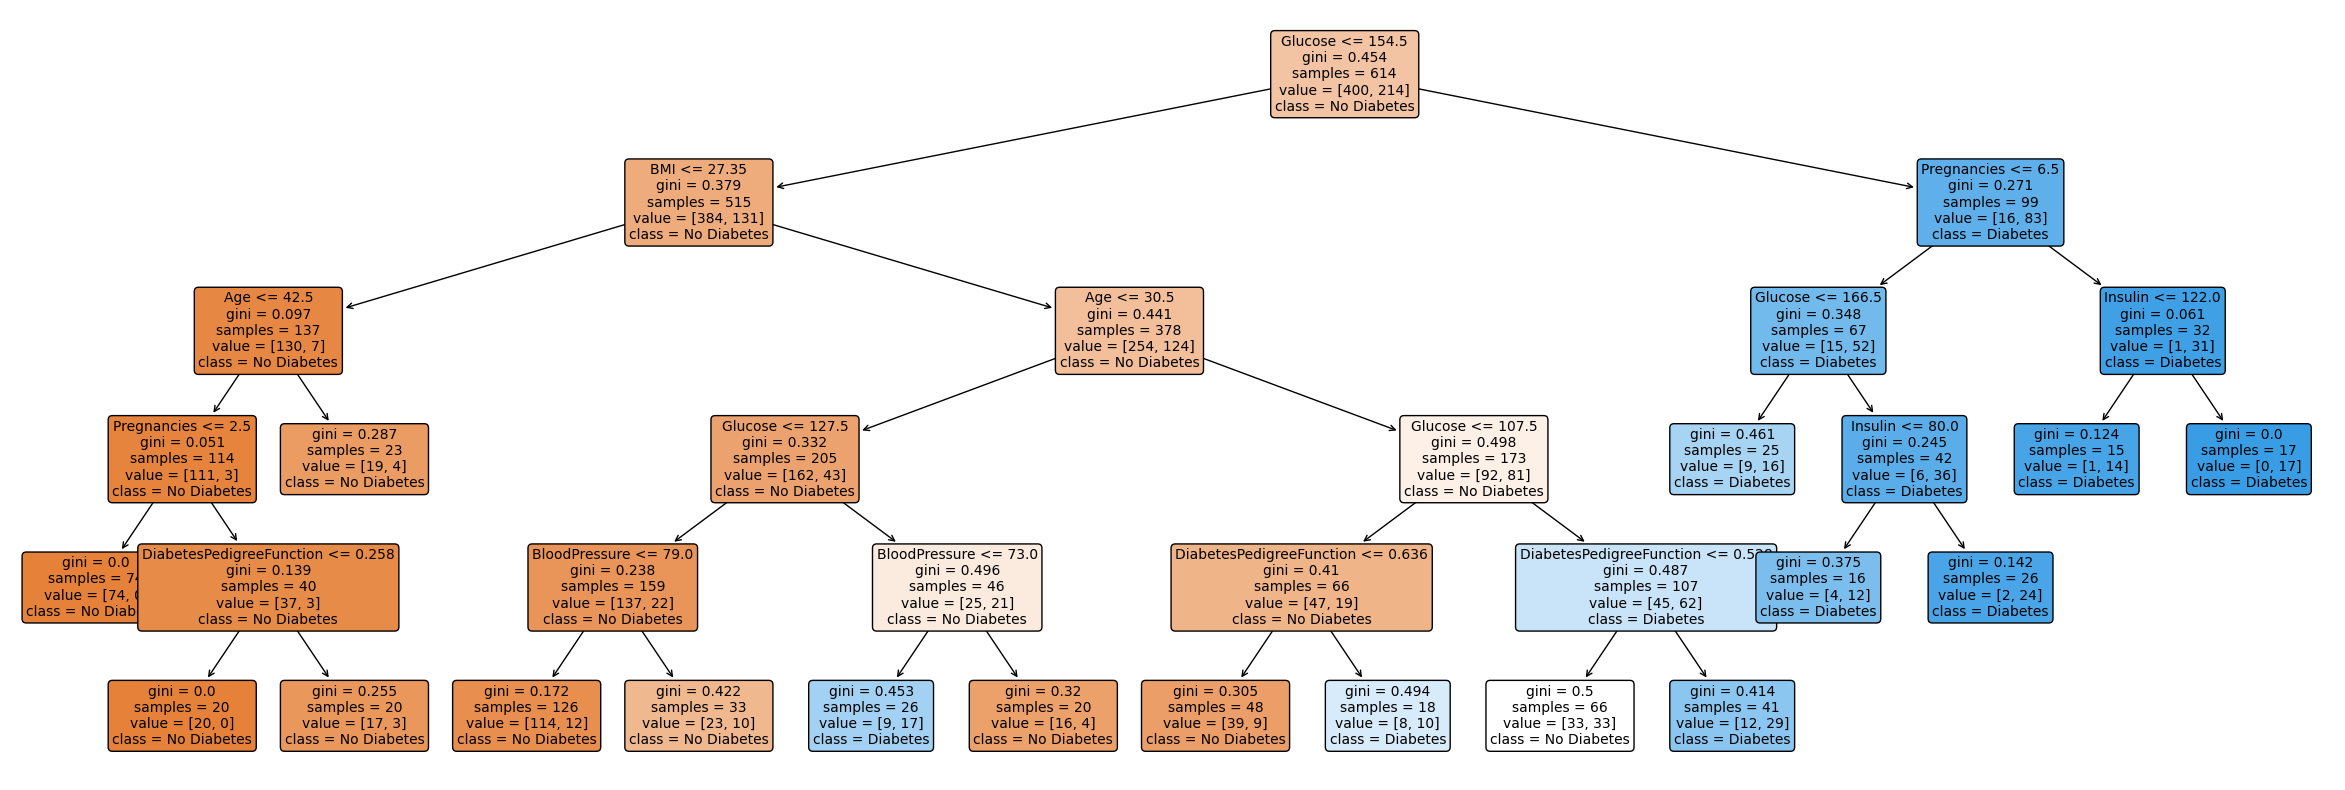

In [58]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30,10))
plot_tree(best_model,
          filled=True,
          rounded=True,
          feature_names=X.columns,
          class_names=['No Diabetes', 'Diabetes'],
          fontsize=10)
plt.show()